# Caption & QA レビュー

ランダムにサンプリングした5フレームについて、元画像・マスク・キャプション・QAをまとめて確認する。

In [1]:
# ========= 設定 =========
N_SAMPLES   = 5
RANDOM_SEED = 42

CAPTION_CSV = "../output/v1/cap_all.csv"   # 使いたい caption CSV に変更
QA_CSV      = "../output/v1/qa_all.csv"    # 使いたい QA CSV に変更
ZIP_PATH    = "../data/cholec80/cholecseg.zip"

In [2]:
import io
import zipfile

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
from IPython.display import display, HTML
from PIL import Image

In [3]:
df_cap = pd.read_csv(CAPTION_CSV)
df_qa  = pd.read_csv(QA_CSV)

print(f"caption: {len(df_cap)} rows / qa: {len(df_qa)} rows")
df_cap.head(3)

caption: 30 rows / qa: 90 rows


,mask_path,video,frame,phase,caption,phase_description,anatomy_present,tools_present,focus_of_frame
0,../data/cholec80/seg/video26/video26_01935/fra...,26,1975,Preparation,A laparoscopic grasper retracts the gallbladde...,Preparation — retraction and exposure to ident...,gallbladder;liver;cystic duct;abdominal wall;f...,grasper,Retracting the gallbladder to expose and ident...
1,../data/cholec80/seg/video12/video12_19500/fra...,12,19572,GallbladderDissection,The gallbladder is being dissected from the li...,Gallbladder dissection and cystic duct exposure,gallbladder;liver;hepatic vein;cystic duct;con...,grasper;L-hook electrocautery (hook cautery),Using L-hook electrocautery to dissect the gal...
2,../data/cholec80/seg/video01/video01_16425/fra...,1,16493,CalotTriangleDissection,The laparoscopic view shows the gallbladder ad...,Calot's triangle dissection — exposing and ske...,gallbladder;liver;cystic duct;peritoneal fat /...,grasper,Retracting the gallbladder and dissecting fat/...


In [4]:
sample_frames = df_cap.sample(n=N_SAMPLES, random_state=RANDOM_SEED).reset_index(drop=True)
sample_frames[["video", "frame", "phase"]]

,video,frame,phase
0,52,2920,CalotTriangleDissection
1,24,292,Preparation
2,52,2853,CalotTriangleDissection
3,12,20058,GallbladderDissection
4,43,505,Preparation


In [5]:
def mask_path_to_zip_key(mask_path: str) -> str:
    """CSVの mask_path から zip内のパスを導出する。
    例: ../data/cholec80/seg/video26/video26_01935/frame_1975_endo_color_mask.png
     -> video26/video26_01935/frame_1975_endo_color_mask.png
    """
    return mask_path.split("seg/", 1)[1]


def load_image_from_zip(zf: zipfile.ZipFile, zip_key: str) -> Image.Image:
    with zf.open(zip_key) as f:
        return Image.open(io.BytesIO(f.read())).copy()


def get_original_key(mask_key: str) -> str:
    """color_mask パスから元画像パスを導出。"""
    return mask_key.replace("_color_mask", "")

In [6]:
def render_qa(qas: pd.DataFrame) -> str:
    """QAをHTML文字列で返す。正解選択肢を緑でハイライト。"""
    html = ""
    for _, qa in qas.iterrows():
        html += f'<p><b>Q{int(qa["qa_id"])}. {qa["question"]}</b></p><ol start="0" style="margin-top:4px">'
        correct = int(qa["correct_option_index"])
        for i in range(6):
            opt = qa.get(f"option_{i}", "")
            if i == correct:
                html += f'<li style="color:green"><b>{opt}</b> ✓</li>'
            else:
                html += f'<li>{opt}</li>'
        html += f'</ol><p style="color:#555;font-size:0.9em">Rationale: {qa["rationale"]}</p><hr>'
    return html


def show_frame(row: pd.Series, zf: zipfile.ZipFile) -> None:
    mask_key = mask_path_to_zip_key(row["mask_path"])
    orig_key = get_original_key(mask_key)

    img_orig = load_image_from_zip(zf, orig_key)
    img_mask = load_image_from_zip(zf, mask_key)

    # --- 画像表示 ---
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].imshow(img_orig)
    axes[0].set_title("Original frame", fontsize=12)
    axes[0].axis("off")
    axes[1].imshow(img_mask)
    axes[1].set_title("Color segmentation mask", fontsize=12)
    axes[1].axis("off")
    fig.suptitle(
        f"video{int(row['video']):02d}  frame {int(row['frame'])}  [{row['phase']}]",
        fontsize=13, fontweight="bold",
    )
    plt.tight_layout()
    plt.show()

    # --- Caption ---
    display(HTML(f"""
    <div style='background:#f8f8f8;padding:12px;border-left:4px solid #4a90d9;margin-bottom:8px'>
      <b>Caption:</b> {row['caption']}<br><br>
      <b>Phase:</b> {row['phase_description']}<br>
      <b>Anatomy:</b> {row['anatomy_present']}<br>
      <b>Tools:</b> {row['tools_present']}<br>
      <b>Focus:</b> {row['focus_of_frame']}
    </div>
    """))

    # --- QA ---
    qas = df_qa[(df_qa["video"] == int(row["video"])) & (df_qa["frame"] == int(row["frame"]))]
    display(HTML(render_qa(qas)))

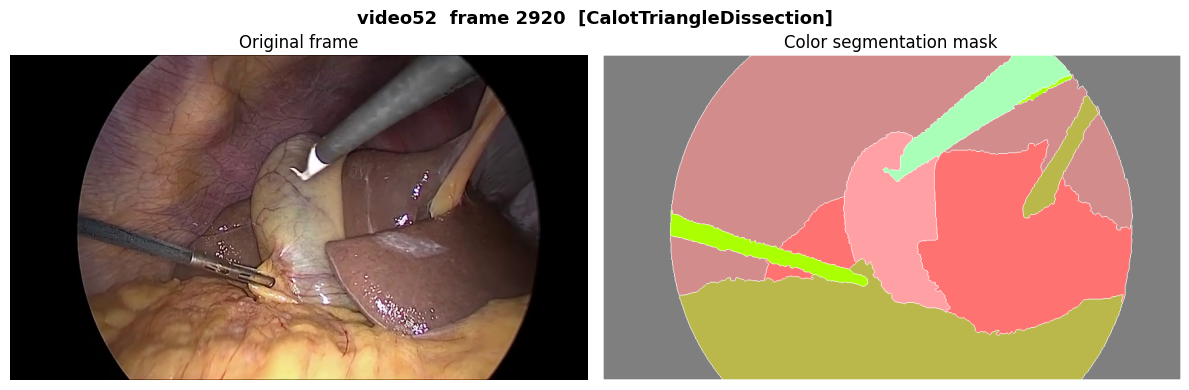

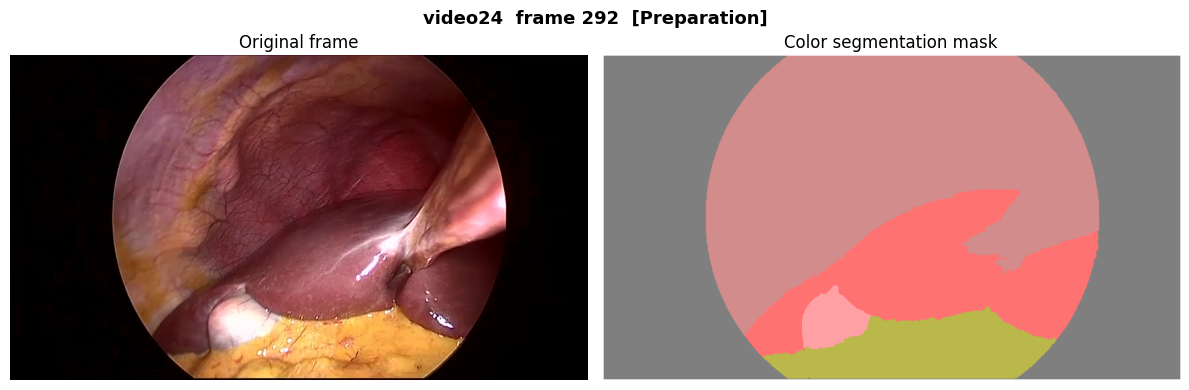

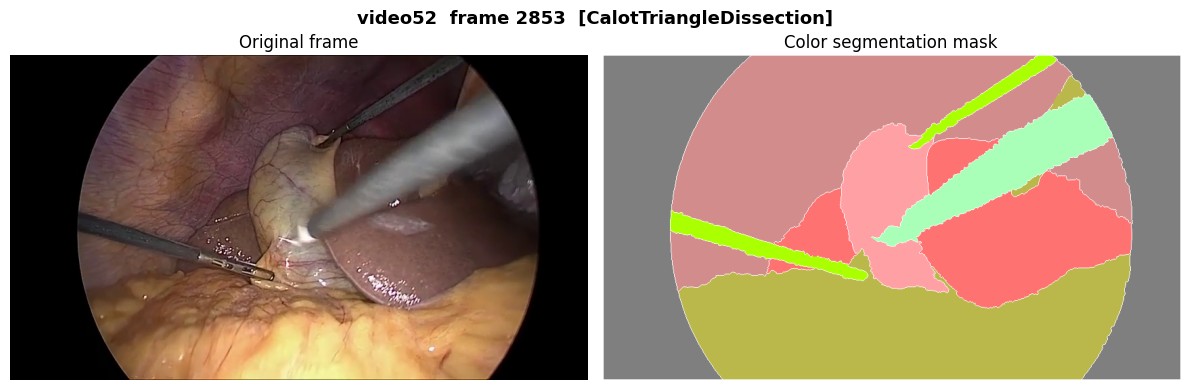

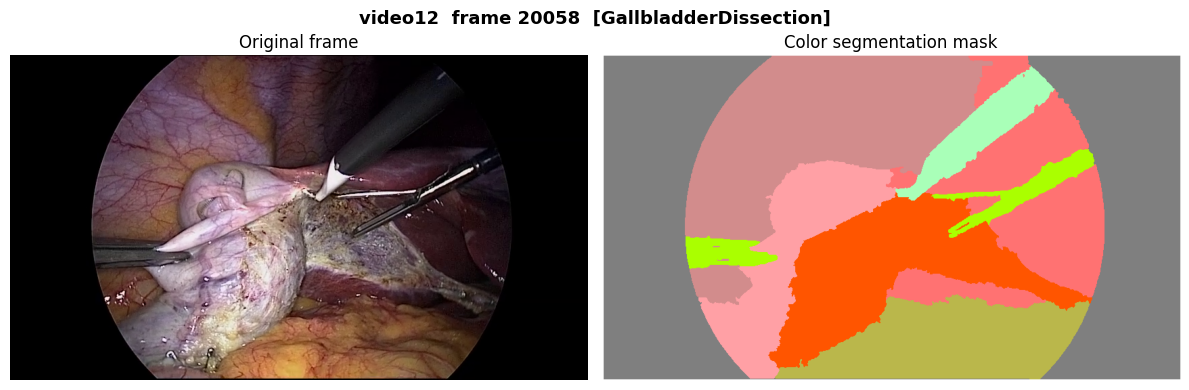

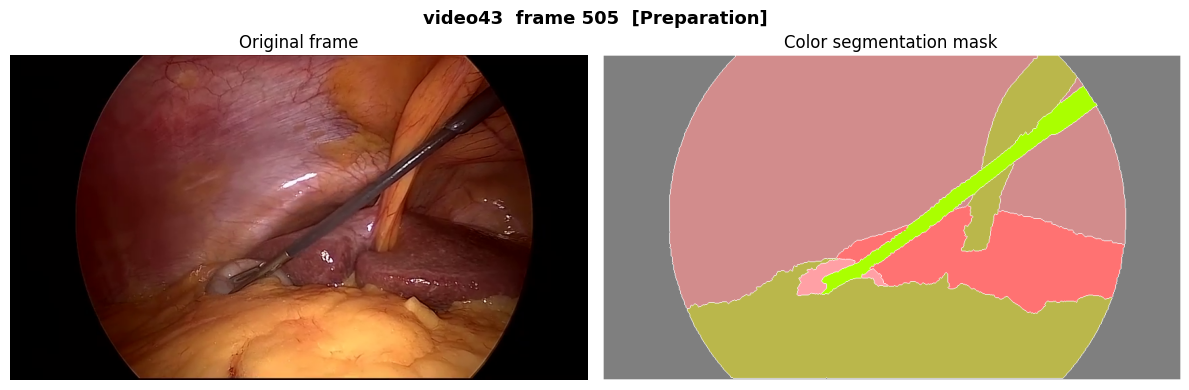

In [7]:
with zipfile.ZipFile(ZIP_PATH) as zf:
    for _, row in sample_frames.iterrows():
        show_frame(row, zf)
        print()